In [3]:
import pandas as pd

In [4]:
raw = pd.read_csv('/work/Experimental-Psycholinguistics-hello-Ethan-/combined_data.csv')

tilføj "/work/" til starten af the path

In [5]:
# raw

In [6]:
# raw.head(20)

In [7]:
# raw.tail(20)

In [8]:
list(raw)
#this gets me the name of all the colums

['participant_id',
 'component_num',
 'url',
 'meta',
 'sender',
 'sender_type',
 'sender_id',
 'ended_on',
 'duration',
 'time_run',
 'time_render',
 'time_show',
 'time_end',
 'time_commit',
 'timestamp',
 'time_switch',
 'response',
 'response_action',
 'prime',
 'target',
 'condition',
 'soa_condition',
 'congruence',
 'correct_response',
 'correctResponse',
 'correct']

now we look at the colums (from the list) that we want

(the reason there is both a corret_response and a correctResponse is bc ethan was silly)

In [9]:
cols = ['participant_id', 'sender', 'duration', 'prime', 'target', 'response', 'condition', 'soa_condition',
        'congruence', 'correct_response', 'correct']

In [10]:
df = raw[cols]

In [11]:
df = df[df['sender'] == 'target']
# making a new dataframe
# this is to exclude the data for when the tester just saw the welcome screen etc.
# it does however include the practice rounds as well

In [12]:
df

,participant_id,sender,duration,prime,target,response,condition,soa_condition,congruence,correct_response,correct
13,51,target,843.38,snjghf,SHEEP,n,practice,practice,practice,n,True
19,51,target,593.04,iweonf,BOAT,m,practice,practice,practice,m,True
25,51,target,559.18,nvoiuh,HOUSE,m,practice,practice,practice,m,True
31,51,target,653.76,abjdhjs,HORSE,n,practice,practice,practice,n,True
40,51,target,520.14,roof,PIANO,m,Inc_Synth_Synth,long,incongruent,m,True
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,699.20,belt,BELT,m,Con_Synth,short,congruent,m,True
15612,69,target,580.20,daisy,DAISY,n,Con_Nat,short,congruent,n,True
15618,69,target,577.90,peach,SHED,m,Inc_Nat_Synth,short,incongruent,m,True
15624,69,target,661.10,rake,HUSKY,n,Inc_Synth_Nat,short,incongruent,n,True


In [13]:
sender_list = list(df['sender'])
set(sender_list) #to see if there are any duplicates

{'target'}

In [14]:
#another way: using a built in pandas way
df['sender'].unique()
#"look in the dataframe in the sender column and show all the unique items"

<StringArray>
['target']
Length: 1, dtype: str

In [15]:
df = df[df['condition'] != 'practice']
#"make the dataframe so that the condition column includes everything BUT 'practice'"

now that we know all the things work, it is more manageable to have the entire script in one cell,
but that can wait.

ethan will upload a clean file for us later anyways

In [16]:
#ethan lavede en fejl da han kodede eksperimentet, som vi lige skal fikses i correct_response column:
df.loc[df['target'] == 'BULL', 'correct_response'] = 'n'
#df.loc[df['target'] == 'BULL', 'correct'] = 'True'
df

,participant_id,sender,duration,prime,target,response,condition,soa_condition,congruence,correct_response,correct
40,51,target,520.14,roof,PIANO,m,Inc_Synth_Synth,long,incongruent,m,True
47,51,target,640.66,sheep,BULL,n,Inc_Nat_Nat,long,incongruent,n,False
54,51,target,597.74,fort,GOAT,n,Inc_Synth_Nat,long,incongruent,n,True
61,51,target,495.68,pear,PEAR,n,Con_Nat,long,congruent,n,True
68,51,target,556.86,olive,MOTOR,m,Inc_Nat_Synth,long,incongruent,m,True
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,699.20,belt,BELT,m,Con_Synth,short,congruent,m,True
15612,69,target,580.20,daisy,DAISY,n,Con_Nat,short,congruent,n,True
15618,69,target,577.90,peach,SHED,m,Inc_Nat_Synth,short,incongruent,m,True
15624,69,target,661.10,rake,HUSKY,n,Inc_Synth_Nat,short,incongruent,n,True


In [17]:
#fixing ethan's mistake in the correct column,
##we make a new column called accuracy that compares response and the fixed correct_response
# df['accuracy'] = df['response'] == [df['correct_response']]

In [24]:
# now we want an avg duration time for a person
# df_grouped = df.groupby(['soa_condition', 'congruence']).mean(['duration'])
# previous linje a kode virker kun på ethans lokale computer af en eller anden grund
# new code from ethan:
df_grouped = df.groupby(['participant_id', 'soa_condition', 'congruence'])['duration'].mean().reset_index()

In [19]:
# this is to make the df look prettier
df_grouped = df_grouped.reset_index()
df_grouped

,index,participant_id,soa_condition,congruence,duration
0,0,51,long,congruent,606.432000
1,1,51,long,incongruent,613.165333
2,2,51,short,congruent,563.862000
3,3,51,short,incongruent,616.752667
4,4,52,long,congruent,710.956667
...,...,...,...,...,...
71,71,68,short,incongruent,984.033333
72,72,69,long,congruent,681.170000
73,73,69,long,incongruent,751.150000
74,74,69,short,congruent,731.553333


In [20]:
# there is a package called matplotlib that can do very nice things, but it is a pain to work with.
# therefor someone made the package seaborn which is the same as matplotlib, but more comprehensible
%pip install seaborn
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


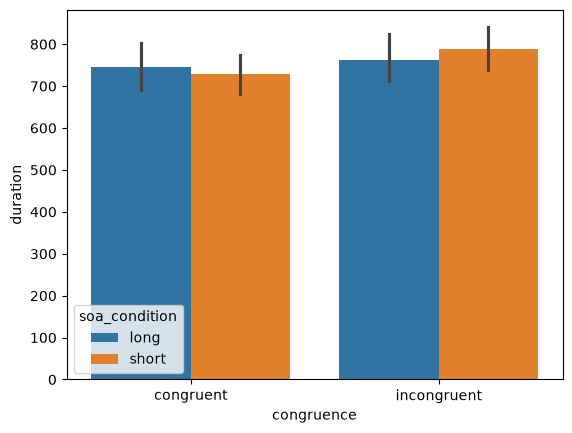

In [21]:
# making a diagram:
## we are however not sure if this is just for one or for all participants
ax = sns.barplot(data = df_grouped, x = 'congruence', y = 'duration',  hue = 'soa_condition')

In [22]:
# moving the little box
sns.move_legend(ax, 'lower right')

so with this we have seen how you can use jupyter to browse your data, filter it and then shape it into a diagram,

without ever even touching the raw data